In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


data_path = 'C:/Users/fusb1/Desktop/Fraud detecting/data/'

X_train = joblib.load(data_path + 'X_train.pkl')
X_test = joblib.load(data_path + 'X_test.pkl')
y_train = joblib.load(data_path + 'y_train.pkl')
y_test = joblib.load(data_path + 'y_test.pkl')


LOGISTIC REGRESSION

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

      Обычные       1.00      0.97      0.98     85335
Мошеннические       0.04      0.90      0.07       108

     accuracy                           0.97     85443
    macro avg       0.52      0.93      0.53     85443
 weighted avg       1.00      0.97      0.98     85443


ROC-AUC: 0.9792


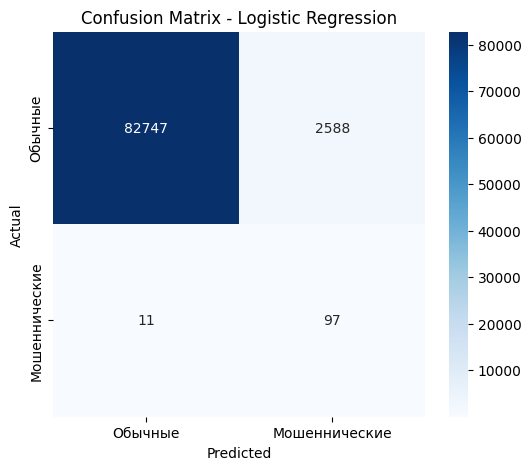

In [12]:
print("LOGISTIC REGRESSION")

model_lr = LogisticRegression(
    class_weight='balanced', 
    max_iter=2000,           
    solver='liblinear',      
    random_state=42
)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_lr, target_names=['Обычные', 'Мошеннические']))

print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Обычные', 'Мошеннические'],
            yticklabels=['Обычные', 'Мошеннические'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()




#Запустил Logistic Regression

RANDOM FOREST

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

      Обычные       1.00      1.00      1.00     85335
Мошеннические       0.96      0.75      0.84       108

     accuracy                           1.00     85443
    macro avg       0.98      0.87      0.92     85443
 weighted avg       1.00      1.00      1.00     85443


ROC-AUC: 0.9766


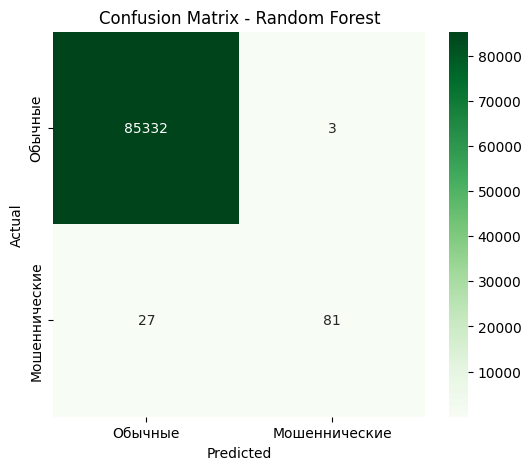

In [ ]:
print("RANDOM FOREST")

model_rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf, target_names=['Обычные', 'Мошеннические']))

print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Обычные', 'Мошеннические'],
            yticklabels=['Обычные', 'Мошеннические'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Запустил RANDOM FOREST

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print(f"{'Порог':<10} {'Recall':<10} {'Precision':<12} {'F1':<10} {'Ложных тревог':<15} {'Пропущено':<12}")
print("-" * 75)

for thresh in thresholds:
    y_pred_custom = (y_prob_rf >= thresh).astype(int)
    recall = recall_score(y_test, y_pred_custom)
    precision = precision_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    false_alarms = ((y_test == 0) & (y_pred_custom == 1)).sum()
    missed = ((y_test == 1) & (y_pred_custom == 0)).sum()
    print(f"{thresh:<10} {recall:<10.3f} {precision:<12.3f} {f1:<10.3f} {false_alarms:<15} {missed:<12}")

#Анализ порогов Random Forest

Порог      Recall     Precision    F1         Ложных тревог   Пропущено   
---------------------------------------------------------------------------
0.3        0.787      0.607        0.685      55              23          
0.4        0.769      0.874        0.818      12              25          
0.5        0.750      0.964        0.844      3               27          
0.6        0.750      0.976        0.848      2               27          
0.7        0.713      0.987        0.828      1               31          
0.8        0.648      0.986        0.782      1               38          


c:\Users\fusb1\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:44:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



CLASSIFICATION REPORT:
               precision    recall  f1-score   support

      Обычные       1.00      1.00      1.00     85335
Мошеннические       0.59      0.77      0.67       108

     accuracy                           1.00     85443
    macro avg       0.80      0.88      0.83     85443
 weighted avg       1.00      1.00      1.00     85443


ROC-AUC: 0.9714


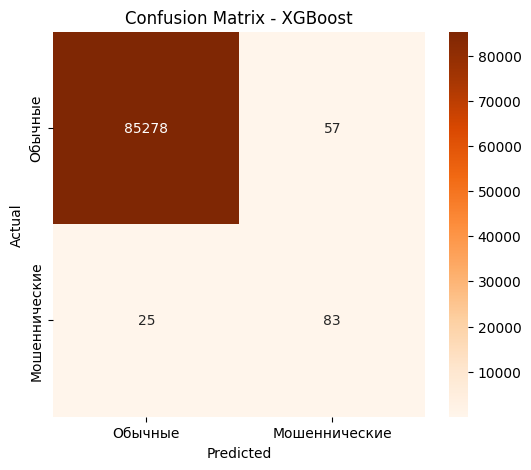


Confusion Matrix (цифры):
  Обычные -> Обычные: 85278
  Обычные -> Мошенники: 57
  Мошенники -> Обычные: 25
  Мошенники -> Мошенники: 83
ВЛИЯНИЕ ПОРОГА НА XGBOOST
Порог      Recall     Precision    F1         Ложных тревог   Пропущено   
---------------------------------------------------------------------------
0.3        0.787      0.386        0.518      135             23          
0.4        0.769      0.506        0.610      81              25          
0.5        0.769      0.593        0.669      57              25          
0.6        0.769      0.648        0.703      45              25          
0.7        0.769      0.728        0.748      31              25          
0.8        0.769      0.798        0.783      21              25          


In [14]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_xgb, target_names=['Обычные', 'Мошеннические']))

print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


# Матрица ошибок с визуализацией
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Обычные', 'Мошеннические'],
            yticklabels=['Обычные', 'Мошеннические'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nConfusion Matrix (цифры):")
print(f"  Обычные -> Обычные: {cm[0,0]}")
print(f"  Обычные -> Мошенники: {cm[0,1]}")
print(f"  Мошенники -> Обычные: {cm[1,0]}")
print(f"  Мошенники -> Мошенники: {cm[1,1]}")

print("ВЛИЯНИЕ ПОРОГА НА XGBOOST")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print(f"{'Порог':<10} {'Recall':<10} {'Precision':<12} {'F1':<10} {'Ложных тревог':<15} {'Пропущено':<12}")
print("-" * 75)

for thresh in thresholds:
    y_pred_custom = (y_prob_xgb >= thresh).astype(int)
    recall = recall_score(y_test, y_pred_custom)
    precision = precision_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    false_alarms = ((y_test == 0) & (y_pred_custom == 1)).sum()
    missed = ((y_test == 1) & (y_pred_custom == 0)).sum()
    print(f"{thresh:<10} {recall:<10.3f} {precision:<12.3f} {f1:<10.3f} {false_alarms:<15} {missed:<12}")

#Запустил XGBoost